In [1]:
import pandas as pd
train_data  = pd.read_csv("data/train.csv", index_col='id').dropna()
test_data = pd.read_csv("data/test.csv", index_col='id').dropna()
train_data

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
id,,,,,,,,
0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert
1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert
3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert
7,2.0,No,8.0,3.0,No,4.0,5.0,Extrovert
9,1.0,No,8.0,6.0,No,14.0,9.0,Extrovert
...,...,...,...,...,...,...,...,...
18509,1.0,No,3.0,4.0,No,15.0,4.0,Extrovert
18511,0.0,No,4.0,5.0,No,11.0,4.0,Extrovert
18514,6.0,No,5.0,3.0,No,10.0,4.0,Extrovert


In [2]:
import seaborn as sns

from sklearn.discriminant_analysis import StandardScaler


scaler = StandardScaler()
num_cols = list(train_data.select_dtypes(exclude=['object']).columns)

train_data[num_cols] = scaler.fit_transform(train_data[num_cols])
test_data[num_cols] = scaler.transform(test_data[num_cols])

train_data

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
id,,,,,,,,
0,-1.001004,No,0.122633,-0.236003,No,1.595076,-0.184829,Extrovert
1,-0.620847,No,0.507691,-0.766592,No,0.367511,0.922299,Extrovert
3,0.139467,No,0.507691,-0.766592,No,0.613024,-0.184829,Extrovert
7,-0.240690,No,0.892749,-0.766592,No,-1.105568,-0.184829,Extrovert
9,-0.620847,No,0.892749,0.825176,No,1.349563,1.291341,Extrovert
...,...,...,...,...,...,...,...,...
18509,-0.620847,No,-1.032539,-0.236003,No,1.595076,-0.553872,Extrovert
18511,-1.001004,No,-0.647482,0.294587,No,0.613024,-0.553872,Extrovert
18514,1.279938,No,-0.262424,-0.766592,No,0.367511,-0.553872,Extrovert


In [3]:
from sklearn.calibration import LabelEncoder


labelEncoder = LabelEncoder()
cat_cols = list(train_data.select_dtypes(include=['object']).columns.difference(['Personality']))

for col_name in cat_cols:
    train_data[col_name]=labelEncoder.fit_transform(train_data[col_name]).astype(int)
    test_data[col_name]=labelEncoder.transform(test_data[col_name]).astype(int)



train_data['Personality'] = labelEncoder.fit_transform(train_data['Personality'])
train_data

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
id,,,,,,,,
0,-1.001004,0,0.122633,-0.236003,0,1.595076,-0.184829,0
1,-0.620847,0,0.507691,-0.766592,0,0.367511,0.922299,0
3,0.139467,0,0.507691,-0.766592,0,0.613024,-0.184829,0
7,-0.240690,0,0.892749,-0.766592,0,-1.105568,-0.184829,0
9,-0.620847,0,0.892749,0.825176,0,1.349563,1.291341,0
...,...,...,...,...,...,...,...,...
18509,-0.620847,0,-1.032539,-0.236003,0,1.595076,-0.553872,0
18511,-1.001004,0,-0.647482,0.294587,0,0.613024,-0.553872,0
18514,1.279938,0,-0.262424,-0.766592,0,0.367511,-0.553872,0


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

train, test = train_test_split(train_data, test_size=0.2)
X = train.iloc[:, 0:-1]
y = train.Personality

model = LogisticRegression(penalty=None, random_state=42)
model.fit(X, y)

LogisticRegression(penalty=None, random_state=42)

In [5]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score


X_test = test.iloc[:, 0:-1]
preds = model.predict(X_test)

y_test = test.Personality
print(
accuracy_score(y_test, preds),

recall_score(y_test, y_pred=preds),
precision_score(y_test, y_pred=preds),
f1_score(y_test, preds))

0.9700686947988224 0.9041916167664671 0.9123867069486404 0.9082706766917293


In [6]:
model.coef_

array([[ 0.44311237,  2.95219741, -0.22409844,  0.23374563,  1.86480051,
        -0.10243744, -0.11420652]])

In [7]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix

data = confusion_matrix(y_test, preds)

index = ['Actual Negative', 'Actual Positive']
columns = ['Predicted Negative', 'Predicted Positive']

# Base crosstab
df = pd.DataFrame(data, index=index, columns=columns)

# Add totals
df['Row Total'] = df.sum(axis=1)
df.loc['Column Total'] = df.sum()

df


,Predicted Negative,Predicted Positive,Row Total
Actual Negative,1675,29,1704
Actual Positive,32,302,334
Column Total,1707,331,2038


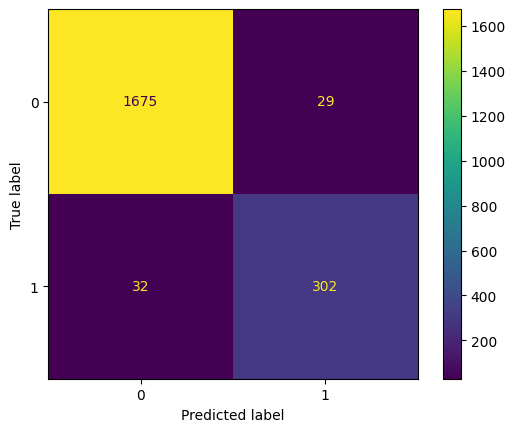

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

_ = ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

### Without dropping Nan 
instead replaced them with modes


In [53]:
train_data  = pd.read_csv("data/train.csv", index_col='id')



train_data

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
id,,,,,,,,
0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert
1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert
2,6.0,Yes,1.0,0.0,NaN,3.0,0.0,Introvert
3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert
4,1.0,No,4.0,4.0,No,13.0,NaN,Extrovert
...,...,...,...,...,...,...,...,...
18519,3.0,No,7.0,3.0,No,9.0,7.0,Extrovert
18520,1.0,NaN,6.0,7.0,No,6.0,5.0,Extrovert
18521,7.0,Yes,1.0,1.0,Yes,1.0,NaN,Introvert


In [54]:
import pandas as pd

train_data = train_data.apply(lambda col: col.fillna(col.mode().iloc[0]) if col.isnull().any() else col)
train_data


,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
id,,,,,,,,
0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert
1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert
2,6.0,Yes,1.0,0.0,No,3.0,0.0,Introvert
3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert
4,1.0,No,4.0,4.0,No,13.0,3.0,Extrovert
...,...,...,...,...,...,...,...,...
18519,3.0,No,7.0,3.0,No,9.0,7.0,Extrovert
18520,1.0,No,6.0,7.0,No,6.0,5.0,Extrovert
18521,7.0,Yes,1.0,1.0,Yes,1.0,3.0,Introvert


In [55]:
scaler = StandardScaler()
num_cols = list(train_data.select_dtypes(exclude=['object']).columns)

train_data[num_cols] = scaler.fit_transform(train_data[num_cols])
test_data[num_cols] = scaler.transform(test_data[num_cols])

In [56]:
# Object datatype columns encoding

labelEncoder = LabelEncoder()
cat_cols = list(train_data.select_dtypes(include=['object']).columns.difference(['Personality']))

for col_name in cat_cols:
    train_data[col_name]=labelEncoder.fit_transform(train_data[col_name]).astype(int)
    
train_data['Personality'] = labelEncoder.fit_transform(train_data['Personality'])
train_data

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
id,,,,,,,,
0,-0.976861,0,0.304058,-0.060097,0,1.724555,0.054239,0
1,-0.644164,0,0.676914,-0.561108,0,0.522569,1.116684,0
2,1.019319,1,-1.560223,-2.064139,0,-1.160211,-1.716503,1
3,0.021229,0,0.676914,-0.561108,0,0.762966,0.054239,0
4,-0.644164,0,-0.441655,-0.060097,0,1.243760,-0.654058,0
...,...,...,...,...,...,...,...,...
18519,0.021229,0,0.676914,-0.561108,0,0.282172,0.762535,0
18520,-0.644164,0,0.304058,1.442933,0,-0.439019,0.054239,0
18521,1.352016,1,-1.560223,-1.563128,1,-1.641005,-0.654058,1


In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

train, test = train_test_split(train_data, test_size=0.2)
X = train.iloc[:, 0:-1]
y = train.Personality

model = LogisticRegression(penalty=None, random_state=42)
model.fit(X, y)

LogisticRegression(penalty=None, random_state=42)

In [58]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score


X_test = test.iloc[:, 0:-1]
preds = model.predict(X_test)

y_test = test.Personality
print(
accuracy_score(y_test, preds),

recall_score(y_test, y_pred=preds),
precision_score(y_test, y_pred=preds),
f1_score(y_test, preds))

0.9711201079622133 0.9350372736954207 0.9502164502164502 0.942565754159957


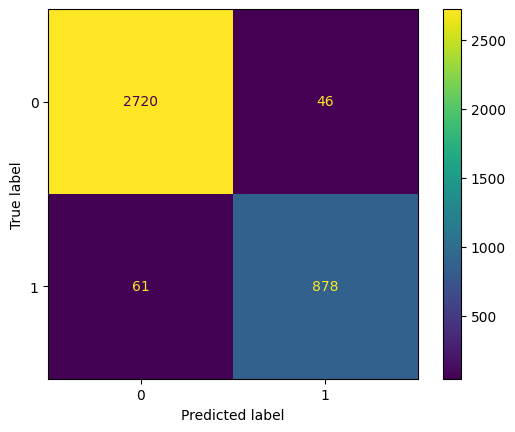

In [59]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

_ = ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

In [219]:
model.coef_
# array([[ 0.49612536,  2.94656233, -0.25986441,  0.1609821 ,  1.48102094,
        # -0.1638331 , -0.13392646]])

array([[ 0.46972825,  4.0697832 , -0.19493477,  0.1808874 ,  1.03044239]])

In [220]:
test_data.isna().sum()

Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
dtype: int64